# <u>Kernel Principal Component Analysis</u>

### Prerequisites:
* <a href="../1.Principal Component Analysis (PCA)/Principal Component Analysis.ipynb">Check out the notebook on Principal Component Analysis</a>


## Topics

* [0. Review of classical (linear) PCA](#review)
* [1. Nonlinear PCA](#nonlinear)
* [2. Problem](#problem)
* [3. Relation between SVD and EVD](#linalg)
* [4. Computational trick](#trick)
* [5. Zero mean](#mean)
* [6. kernel PCA algorithm ](#alg)
* [7. kernel PCA library](#library)

In [ ]:
import numpy as np # for math and random numbers
import plotly.express as px # for plotting
import plotly.graph_objects as go # for plotting
from sklearn.decomposition import PCA # for principal component analysis
from sklearn.datasets import make_regression
print("Setup complete")

<a class="anchor" id="review"></a>
## 0. Review of classical (linear) PCA

**Idea of PCA**
- maximize Variance: $\arg \max_W \lVert W^\top X \rVert^2$

**Results**

- Direction of largest variance = Eigenvector of largest eigenvalue of covariance matrix

- Eigenvectors = principal directions

- Eigenvalues = variance along those directions

- A sharp drop in eigenvalues suggests a good low-dimensional embedding

**Algorithm** (based on EVD of covariance matrix)

1. Given data matrix $X=[x_1,...,x_n] \in \mathbb{R}^{D\times n}$, assume mean is already removed or remove it
2. Calculate sample covariance matrix $\Sigma = \frac{1}{n} \sum_{i=1}^n x_i x_i^\top = \frac{1}{n} XX^\top$
3. Calculate eigenvector decomposition (EVD) $\Sigma = V \Lambda V^\top$
4. $V=[\mathcal{v_1} \hspace{0.2cm} \mathcal{v_2} \hspace{0.2cm} ... \hspace{0.2cm} \mathcal{v_D}]$ contains eigenvectors as columns and $\Lambda = \begin{bmatrix} \lambda_1 & 0 & ... & 0 \\ 0 & \lambda_2 & ... & 0 \\ \vdots & \vdots & \ddots & \vdots \\ 0 & 0 & ... & \lambda_D \end{bmatrix}$ contains corresponding eigenvalues $\lambda_1 \ge \ldots \ge \lambda_D$
5. Pick $d$ largest eigenvalues carrying most of the variance
6. Project data onto $V_d=[\mathcal{v_1} \hspace{0.2cm} \ldots \hspace{0.2cm} \mathcal{v_d}]$, i.e., $Z=V_d^\top X$
7. Possibly rescale axes $Z=\Lambda_d^{-0.5}V_d^\top X$ with $\Lambda_d$ containing $\lambda_1,..,\lambda_d$  (aka whitening) 

<a class="anchor" id="nonlinear"></a>
## 1. Nonlinear PCA

**Goal**
- Find curved coordinate system through data
- Fit by maximizing variance, while keeping the mapping simple


<div style="
background-color:#2f4154;
padding:16px;
border-radius:8px;
color:white;
">

### Kernel trick

**Goal:**
- create a nonlinear version of an existing linear algorithm

**Requirement:**
- the linear algorithm must only calculate inner products $x^\top x$ of the data points

**Kernelization:**
- replace all dot products by a kernel function

**Examples:**
- kernel PCA, kernel LDA, kernel CCA, kernel FDA, kernel ICA, …


</div>

<a class="anchor" id="problem"></a>
## 2. Problem


**Algorithm** (based on EVD of covariance matrix)

1. ...
2. Calculate sample covariance matrix $\Sigma = \frac{1}{n} \sum_{i=1}^n x_i x_i^\top = \frac{1}{n} XX^\top \rightarrow$ Outer product &#10071; 
3. ...
4. ...
5. ...
6. Project data onto $V_d=[\mathcal{v_1} \hspace{0.2cm} \ldots \hspace{0.2cm} \mathcal{v_d}]$, i.e., $Z=V_d^\top X \rightarrow$ Inner product &#9989;
7. ...

**Challenge:** Formulate PCA solely using inner products

<a class="anchor" id="linalg"></a>
## 3. Relation between SVD and EVD

### Singular value decomposition (SVD)

Any matrix $X$ can be factorized into three matrices $$X=USV^\top$$ such that

- $U \in \mathbb{R}^{d \times d}$, $V \in \mathbb{R}^{n \times n}$, $S \in \mathbb{R}^{d \times n}$ with S being diagonal matrix with **singular values (SVs)** on diagonal
- $U$ and $V$ are unitary, i.e. $UU^\top = I_d \in \mathbb{R}^{d \times d}$ and $VV^\top = I_n \in \mathbb{R}^{n \times n}$ (identity matrices)

$$\text{Full-sized SVD}$$
<p align="center">
<img src="pics/SVD graphically.jpeg" width="600"/>
</p>

- Null space of $X$ is $V_2$ so it is not relevant
- Range of $X$ is $U_1$ so $U_2$ can also be dropped

$$\text{Economy-sized SVD}$$

<p align="center">
<img src="pics/SVD graphically 2.jpeg" width="600"/>
</p>


### Eigenvalue decomposition (EVD)

Any symmetric matrix $A$ can be decomposed into $$A=V \Lambda V^\top$$ 

- with $\Lambda$ being diagonal matrix with eigenvalues on diagonal
- with $V$ being unitary matrix, i.e. $VV^\top = V^\top V = I$ with eigenvectors as columns


### Relationship

Consider economy-sized SVD $$X=USV^\top$$

Calculate $XX^\top$ and $X^\top X$:
$$
XX^\top = USV^\top (USV^\top)^\top = USV^\top VS^\top U^\top = USIS^\top U^\top = US^2U^\top = U \Lambda U^\top \\
X^\top X = (USV^\top)^\top USV^\top = VS^\top U^\top USV^\top = VSIS^\top V^\top = VS^2 V^\top = V \Lambda V^\top
$$

- squared singular values (SVs) $S^2$ of $X$ are the eigenvalues of $XX^\top$ and $X^\top X$ ($S^2 = \Lambda \iff S^{-1} = \Lambda^{-\frac{1}{2}}$)
- left singular vectors $U$ of $X$ are the eigenvectors of $XX^\top$
- right singular vectors $V$ of $X$ are the eigenvectors of $X^\top X$


Left SVs can be computed from the right SVs and vice versa:
$$
\text{(1) } U = XV \Lambda^{-\frac{1}{2}} \\
\text{(2) } V = X^\top U \Lambda^{-\frac{1}{2}}
$$

Similar result for the submatrices (Economy-sized SVD)
$$
U_1 = XV_1 \Lambda_1^{-\frac{1}{2}} \\
V_1 = X^\top U_1 \Lambda_1^{-\frac{1}{2}}
$$


Proof: Plug in $X=USV^\top$ to get: 

$$
\text{(1) } U = XV \Lambda^{-\frac{1}{2}} \iff U = USV^\top V \Lambda^{-\frac{1}{2}} \iff U = USI \Lambda^{-\frac{1}{2}} \iff U = USS^{-1} \iff U = U \\
\text{(2) } V = X^\top U \Lambda^{-\frac{1}{2}} \iff V = (USV^\top)^\top U \Lambda^{-\frac{1}{2}} \iff V = VS^\top U^\top U \Lambda^{-\frac{1}{2}} \iff V = VS^\top I S^{-1} \iff V=V

$$



<a class="anchor" id="trick"></a>
## 4. Computational trick



> Consider <b>very</b> high dimensional data points $X=[x_1 \hspace{0.2cm} x_2 \hspace{0.2cm} \ldots \hspace{0.2cm} x_n] \in \mathbb{R}^{D \times n}$ with $D \gg n$




<div style="display:flex; gap:20px;">


<div>

EVD of covariance matrix  $$\Sigma=\frac{1}{n} XX^\top \in \mathbb{R}^{D \times D} $$

- EVD of $XX^\top$ costs $O(D^3)$



</div>


<div>

Idea: Calculate EVD of inner product matrix (aka Gram matrix)
$$
\frac{1}{n}X^\top X = \frac{1}{n} \begin{bmatrix} x_1^\top x_1 & \ldots & x_1^\top x_n \\  \vdots & \ddots & \vdots \\ x_n^\top x_1 & \ldots & x_n^\top x_n   \end{bmatrix} \in \mathbb{R}^{n \times n}
$$

- EVD of $X^\top X$ costs $O(n^3)$


</div>

</div>


> Consider <b>very</b> high dimensional data points $X=[x_1 \hspace{0.2cm} x_2 \hspace{0.2cm} \ldots \hspace{0.2cm} x_n] \in \mathbb{R}^{D \times n}$ with $D \gg n$

**Algorithm (EVD of covariance matrix)**

1. Calculate EVD of the inner product matrix $$ X^\top X = V \Lambda V^\top \in \mathbb{R}^{n \times n}$$
2. Transform the EVs of $X^\top X$ into EVs of $XX^\top$ $$U_1 = X V \Lambda^{-\frac{1}{2}} \in  \mathbb{R}^{D \times n}$$

Economy-sized EVD of rank $n$ of covariance matrix $$XX^\top = U_1 \Lambda U_1^\top \in  \mathbb{R}^{D \times D}$$

Never actually calculate $XX\top$, instead calculate $U_1$ and $\Lambda$

___

**Algorithm (PCA with Gram matrix)**

1. Calculate EVD of Gram matrix $$X^\top X = V \Lambda V^\top \text{ with } \Lambda \text{ also being the EVs of covariance matrix } XX^\top$$

2. Calculate $U$ such that $XX^\top = U \Lambda U^\top$ via $$U=XV\Lambda^{-\frac{1}{2}}$$

3. Project data points onto space spanned by $U_1$ $$Y=U_1^\top X = \Lambda_1^{-\frac{1}{2}}V_1^\top X^\top X$$


<a class="anchor" id="mean"></a>
## 5. Zero mean

Mean of data $$\mu=\frac{1}{n} X \mathcal{1_n} \text{ where }\mathcal{1_n} \text{ is } n \text{ dimensional vector of ones}$$

Removing mean 
$$
X - \mu \mathcal{1_n}^\top = X - \frac{1}{n} X \mathcal{1_n} \mathcal{1_n}^\top = X(I - \frac{1}{n} \mathcal{1_n} \mathcal{1_n}^\top) = XH
$$
- $\mu \mathcal{1_n}^\top \in \mathbb{R}^{D \times n}$
- Centering matrix $H=I - \frac{1}{n} \mathcal{1_n} \mathcal{1_n}^\top$ with properties $H=H^\top$ and $H=HH$
- multiplying X from the right with H removes the mean

Gram matrix $$G = X^\top X$$
Gram matrix for non-zero mean $$G=(XH)^\top (XH)= HX^\top XH $$
Removing mean in feature space $$HKH = H\phi(X)^\top \phi(X)H=(\phi(X)H)^\top (\phi(X)H) \hspace{0.2cm} \text{where } K=\phi(X)^\top \phi(X)$$

<a class="anchor" id="alg"></a>
## 6. kernel PCA algorithm

Given data points $X=[x_1 \hspace{0.2cm} x_2 \hspace{0.2cm} ... \hspace{0.2cm} x_n] \in \mathbb{R}^{D \times n}$

1. Calculate kernel matrix (aka Gram matrix) for some kernel $k$: $$K= \begin{bmatrix} k(x_1, x_1) & \ldots & k(x_1, x_n) \\  \vdots & \ddots & \vdots \\ k(x_n, x_1) & \ldots & k(x_n, x_n)   \end{bmatrix}$$

2. Find eigenvalue decompositon of centered Gram matrix: $$HKH=V \Lambda V^\top$$

3. Project centered data onto eigenvectors: $$Y=\Lambda_1^{-\frac{1}{2}}V_1^\top HKH$$

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

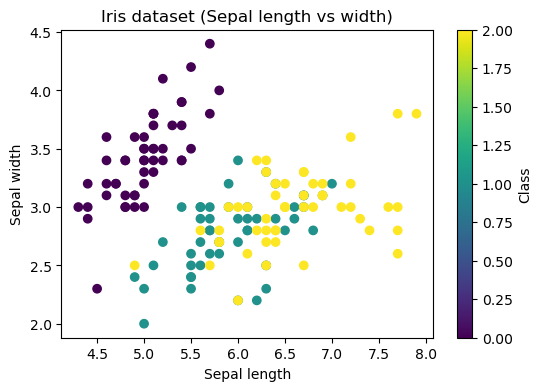

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

iris=load_iris()
print(iris.data)
print(iris.data.shape) # 150 observations divided in 4 features => x1 (sepal length),x2 (sepal width),x3 (petal length),x4 (petal width) (4 dimensions)
print(iris.target)

X_iris = iris.data
y_iris = iris.target

plt.figure(figsize=(6,4))
# pick only columns 1 and 2
plt.scatter(X_iris[:, 0], X_iris[:, 1], c=y_iris, cmap='viridis')
plt.xlabel('Sepal length')
plt.ylabel('Sepal width')
plt.title('Iris dataset (Sepal length vs width)')
plt.colorbar(label='Class')
plt.show()


Centering matrix
$$
H=I - \frac{1}{n} \mathcal{1_n} \mathcal{1_n}^\top
$$

In [3]:
#print(np.outer(np.ones(5), np.ones(5)), "\n") # outer product

def centering(n):
    """
    Centering matrix H = I - (1/n) 11^T
    """
    return np.eye(n) - np.ones((n, n)) / n

##### Gaussian (RBF) kernel

$$
k(x,x')= \exp(-\frac{(x-x')^\top (x-x')}{2\sigma^2}) > 0
$$

- $\sigma^2$ is called bandwidth
- measures similarity, i.e. $k(x,x)=1$ and decreases smoothly as distance increases 
- corresponds to an infinite-dimensional feature space

In [4]:
def rbf_kernel(X, sigma=1.0):
    """
    Compute RBF (Gaussian) kernel matrix
    X: D x n data matrix
    returns: n x n Gram matrix
    """
    X = X.T  # n x D
    sq_norms = np.sum(X**2, axis=1, keepdims=True)
    dist_sq = sq_norms + sq_norms.T - 2 * X @ X.T
    K = np.exp(-dist_sq / (2 * sigma**2))
    return K


In [5]:
def evd(A):
    """
    Eigenvalue decomposition of symmetric matrix
    Returns eigenvalues and eigenvectors in descending order
    """
    vals, vecs = np.linalg.eigh(A)
    idx = np.argsort(vals)[::-1]
    return vals[idx], vecs[:, idx]

### kernel PCA algorithm

Given data points $X=[x_1 \hspace{0.2cm} x_2 \hspace{0.2cm} ... \hspace{0.2cm} x_n] \in \mathbb{R}^{D \times n}$

1. Calculate kernel matrix (aka Gram matrix) for some kernel $k$: $$K= \begin{bmatrix} k(x_1, x_1) & \ldots & k(x_1, x_n) \\  \vdots & \ddots & \vdots \\ k(x_n, x_1) & \ldots & k(x_n, x_n)   \end{bmatrix}$$

2. Find eigenvalue decompositon of centered Gram matrix: $$HKH=V \Lambda V^\top$$

3. Project centered data onto eigenvectors: $$Y=\Lambda_1^{-\frac{1}{2}}V_1^\top HKH$$

In [ ]:
def kernel_pca(X, d, kernel="rbf", sigma=1.0):
    """
    Kernel PCA following above algorithm 
    X: D x n data matrix
    d: number of components
    """
    n = X.shape[1]

    # Kernel matrix (Gram matrix K)
    if kernel == "rbf":
        K = rbf_kernel(X, sigma)
    else:
        raise ValueError("Unsupported kernel") # only use rbf kernel

    # Center kernel matrix
    H = centering(n)
    Kc = H @ K @ H

    # Eigenvalue decomposition
    eigvals, eigvecs = evd(Kc)

    # Select top-d eigenpairs
    eigvals_d = eigvals[:d]
    eigvecs_d = eigvecs[:, :d]

    # Normalize eigenvectors
    eigvecs_d = eigvecs_d / np.sqrt(eigvals_d) 

    # Projection
    Z = eigvecs_d.T @ Kc

    return Z, eigvals



##### Where do we compute $\Lambda_1$ and $V_1$?

```python
    # Eigenvalue decomposition
    eigvals, eigvecs = evd(Kc)

    # Select top-d eigenpairs
    eigvals_d = eigvals[:d]
    eigvecs_d = eigvecs[:, :d]
```
This corresponds to:
- $V_1$ = ``eigvecs_d``
- $\Lambda_1$ = ``diag(eigvals_d)``

So at this point we have: 
$$
Kc = HKH = V_1 \Lambda_1 V_1^\top \text{ (restricted to top d) }
$$

##### Where is $\Lambda_1^{-\frac{1}{2}}$

```python
    # Normalize eigenvectors
    eigvecs_d = eigvecs_d / np.sqrt(eigvals_d) 
```
Dividing each eigenvector $\mathcal{v_i}$ by $\sqrt{\lambda_i}$ is equivalent to $V_1 \Lambda_1^{-\frac{1}{2}} = \Lambda_1^{-\frac{1}{2}} V^\top$ beacause each column $\mathcal{v_i}$ is scaled by $\frac{1}{\sqrt{\lambda_i}}$

So $\Lambda_1^{-\frac{1}{2}}$ is never formed explicitly as a matrix, but its effect is applied here.

##### When do we mcompute $Y=\Lambda_1^{-\frac{1}{2}}V_1^\top HKH$

```python
    # Projection
    Z = eigvecs_d.T @ Kc

```
Substitute  ``eigvecs_d``= $\Lambda_1^{-\frac{1}{2}}V_1^\top$ to get $$Z=\Lambda_1^{-\frac{1}{2}}V_1^\top Kc$$ which is exactly $$Y=\Lambda_1^{-\frac{1}{2}}V_1^\top HKH$$


In [ ]:
# Run Kernel PCA (d = 2)
X_iris = iris.data.T
Z_kpca, eigvals_kpca = kernel_pca(X_iris, d=2, kernel="rbf", sigma=1.0)

print(Z_kpca, Z_kpca.shape) # projected data onto to 2 dimensions from previously 4


In [ ]:
print(eigvals_kpca, eigvals_kpca.shape)

In [ ]:
# Visualization (colored by species)
plt.figure(figsize=(6, 5))

for label in np.unique(y_iris):
    plt.scatter(
        Z_kpca[0, y_iris == label],
        Z_kpca[1, y_iris == label],
        label=iris.target_names[label]
    )

plt.xlabel("kPC 1")
plt.ylabel("kPC 2")
plt.title("Kernel PCA on Iris data (RBF kernel)")
plt.legend()
plt.show()
